In [1]:
# Figure1(A-D)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt
from matplotlib.font_manager import FontProperties
import pyscisci.all as pyscisci
from brokenaxes import brokenaxes
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import LogLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from scipy import stats
from scipy.stats import norm, ks_2samp
from adjustText import adjust_text
from itertools import combinations
from scipy.stats import ttest_ind
import itertools
# 定义字体
EF = FontProperties(family = 'DejaVu Sans')

%matplotlib inline

In [2]:
main_path = r'/home/20250114zmz_kd/'

In [3]:
panel_data = r'Co-utilization/1-Revision202501-DataProcess/9-PanelData_20250303-adddicesimilarity.csv'

pddf = pd.read_csv(main_path + panel_data)
del pddf['Unnamed: 0']
print(pddf .shape)
pddf .columns

(25410, 23)


Index(['work_id', 'facility_pair', 'times_cited_3', 'times_cited_5',
       'times_cited_10', 'di3', 'di5', 'di10', 'energy1-0', 'num_staff_bin',
       'past_experience', 'time_span', 'knowledge_similarity', 'region_d1n0',
       'num_reference', 'published_year', 'num_staff', 'num_author',
       'num_inst', 'num_coun', 'energy_pair', 'workid_facilitypair',
       'DiceSimilarity'],
      dtype='object')

In [4]:
# 提取facilitypair Energypair对应的past_experience和time_span最大值
max_value_energy_experience = pddf.groupby(['facility_pair','energy_pair','energy1-0'])['past_experience'].max().reset_index()
print(max_value_energy_experience .columns)
max_value_energy_experience = max_value_energy_experience  .rename(columns = {'past_experience':'max_experience'})
print(max_value_energy_experience .shape)

Index(['facility_pair', 'energy_pair', 'energy1-0', 'past_experience'], dtype='object')
(411, 4)


In [5]:
max_value_energy_time = pddf.groupby(['facility_pair','energy_pair','energy1-0'])['time_span'].max().reset_index()
print(max_value_energy_time .columns)
max_value_energy_time = max_value_energy_time .rename(columns = {'time_span':'max_time_span'})
print(max_value_energy_time .shape)

Index(['facility_pair', 'energy_pair', 'energy1-0', 'time_span'], dtype='object')
(411, 4)


In [6]:
max_value_region_experience = pddf.groupby(['facility_pair','region_d1n0'])['past_experience'].max().reset_index()
print(max_value_region_experience .columns)
max_value_region_experience = max_value_region_experience .rename(columns = {'past_experience':'max_experience'})
print(max_value_region_experience .shape)

Index(['facility_pair', 'region_d1n0', 'past_experience'], dtype='object')
(411, 3)


In [7]:
max_value_region_time = pddf.groupby(['facility_pair','region_d1n0'])['time_span'].max().reset_index()
print(max_value_region_time .columns)
max_value_region_time = max_value_region_time .rename(columns = {'time_span':'max_time_span'})
print(max_value_region_time .shape)

Index(['facility_pair', 'region_d1n0', 'time_span'], dtype='object')
(411, 3)


max_experience t-test: -1.8904816567917913 0.05940083533165573
max_time_span t-test: -1.7849028424488098 0.07506675577284791
max_experience t-test: 4.1827885245898155 5.76904774577468e-05
max_time_span t-test: 3.378860172642861 0.0009158791004383606


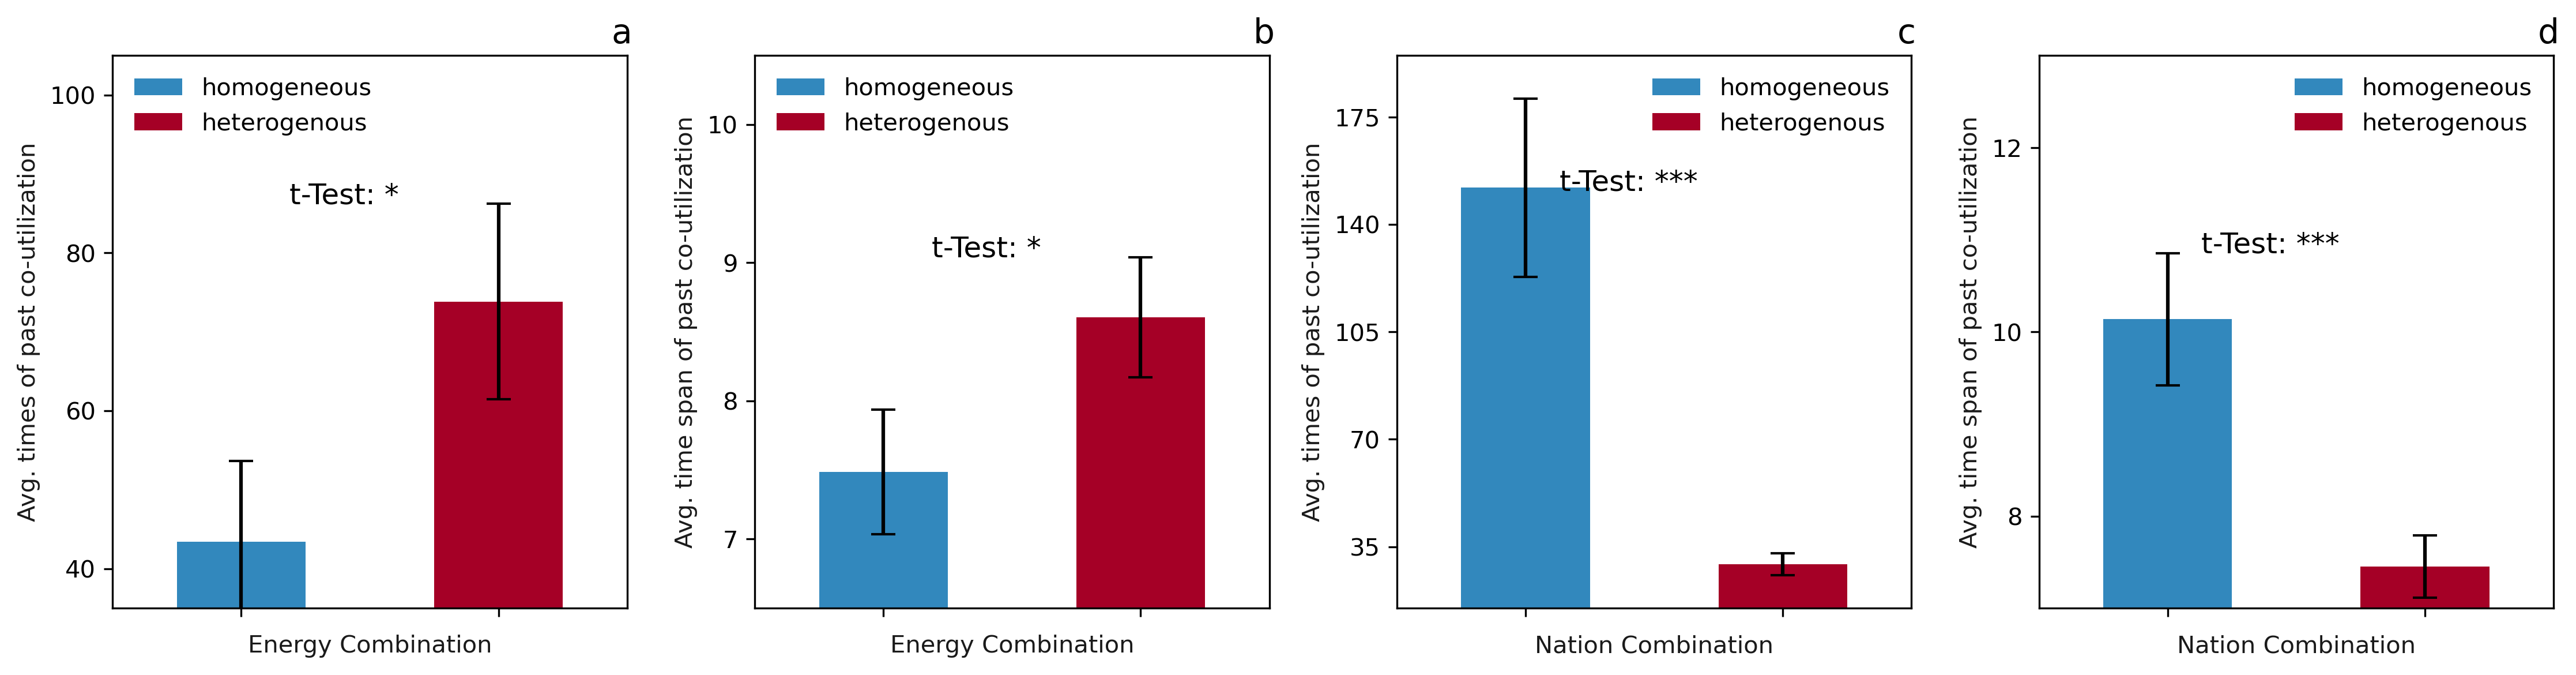

In [8]:
fig, axes = plt.subplots(1, 4, figsize = (15,4), dpi = 300)

df0 = max_value_energy_experience
# 计算均值和SEM
group0_stats = df0.groupby('energy1-0')['max_experience'].agg(['mean','sem']).reset_index()
# 画柱状图+误差棒
axes[0].bar(1, group0_stats[group0_stats['energy1-0']==0]['mean'], 
            yerr=group0_stats[group0_stats['energy1-0']==0]['sem'], 
            color = '#3288bd', label = 'homogeneous', width = 0.5, capsize=5)
axes[0].bar(2, group0_stats[group0_stats['energy1-0']==1]['mean'], 
            yerr=group0_stats[group0_stats['energy1-0']==1]['sem'], 
            color = '#a50026', label = 'heterogenous', width = 0.5, capsize=5)
# t-test
data0 = df0[df0['energy1-0']==0]['max_experience'].dropna()
data1 = df0[df0['energy1-0']==1]['max_experience'].dropna()
t_stat, p_value = ttest_ind(data0, data1, equal_var=False)
print('max_experience t-test:', t_stat, p_value)
# 显著性标注
if p_value < 0.01:
    sig = '***'
elif p_value < 0.05:
    sig = '**'
elif p_value < 0.1:
    sig = '*'
else:
    sig = f'p={p_value:.3f}'
y_max = max(group0_stats['mean'] + group0_stats['sem'])  # 标注位置可适当调整
axes[0].text(1.4, y_max, f't-Test: {sig}', ha='center', fontsize=12)
axes[0].set_ylabel('Avg. times of past co-utilization', fontsize=10, fontproperties=EF, color='#1a1a1a')
axes[0].set_xlabel('Energy Combination', fontsize=10, fontproperties=EF, color='#1a1a1a')
axes[0].set_ylim(35, 105)
axes[0].yaxis.set_major_locator(MultipleLocator(20))
axes[0].set_xlim(0.5, 2.5)
axes[0].set_xticks([1,2])
axes[0].set_xticklabels(['',''])
axes[0].legend(frameon=False, prop={'family': EF.get_name(), 'size': 10}, loc='upper left')

df1 = max_value_energy_time
group1_stats = df1.groupby('energy1-0')['max_time_span'].agg(['mean','sem']).reset_index()
# 画柱状图+误差棒
axes[1].bar(1, group1_stats[group1_stats['energy1-0']==0]['mean'], 
            yerr=group1_stats[group1_stats['energy1-0']==0]['sem'], 
            color = '#3288bd', label = 'homogeneous', width = 0.5, capsize=5)
axes[1].bar(2, group1_stats[group1_stats['energy1-0']==1]['mean'], 
            yerr=group1_stats[group1_stats['energy1-0']==1]['sem'], 
            color = '#a50026', label = 'heterogenous', width = 0.5, capsize=5)
# t-test
data0 = df1[df1['energy1-0']==0]['max_time_span'].dropna()
data1 = df1[df1['energy1-0']==1]['max_time_span'].dropna()
t_stat, p_value = ttest_ind(data0, data1, equal_var=False)
print('max_time_span t-test:', t_stat, p_value)
# 显著性标注
if p_value < 0.01:
    sig = '***'
elif p_value < 0.05:
    sig = '**'
elif p_value < 0.1:
    sig = '*'
else:
    sig = f'p={p_value:.3f}'
y_max = max(group1_stats['mean'] + group1_stats['sem'])  # 标注位置可适当调整
axes[1].text(1.4, y_max, f't-Test: {sig}', ha='center', fontsize=12)
axes[1].set_ylabel('Avg. time span of past co-utilization', fontsize=10, fontproperties=EF, color='#1a1a1a')
axes[1].set_xlabel('Energy Combination', fontsize=10, fontproperties=EF, color='#1a1a1a')
axes[1].set_ylim(6.5, 10.5)
axes[1].yaxis.set_major_locator(MultipleLocator(1))
axes[1].set_xlim(0.5, 2.5)
axes[1].set_xticks([1,2])
axes[1].set_xticklabels(['',''])
axes[1].legend(frameon=False, prop={'family': EF.get_name(), 'size': 10}, loc='upper left')


df2 = max_value_region_experience
group2_stats = df2.groupby('region_d1n0')['max_experience'].agg(['mean','sem']).reset_index()
# 画柱状图+误差棒
axes[2].bar(1, group2_stats[group2_stats['region_d1n0']==0]['mean'], 
            yerr=group2_stats[group2_stats['region_d1n0']==0]['sem'], 
            color = '#3288bd', label = 'homogeneous', width = 0.5, capsize=5)
axes[2].bar(2, group2_stats[group2_stats['region_d1n0']==1]['mean'], 
            yerr=group2_stats[group2_stats['region_d1n0']==1]['sem'], 
            color = '#a50026', label = 'heterogenous', width = 0.5, capsize=5)
# t-test
data0 = df2[df2['region_d1n0']==0]['max_experience'].dropna()
data1 = df2[df2['region_d1n0']==1]['max_experience'].dropna()
t_stat, p_value = ttest_ind(data0, data1, equal_var=False)
print('max_experience t-test:', t_stat, p_value)
# 显著性标注
if p_value < 0.01:
    sig = '***'
elif p_value < 0.05:
    sig = '**'
elif p_value < 0.1:
    sig = '*'
else:
    sig = f'p={p_value:.3f}'
y_max = max(group2_stats['mean'] + group2_stats['sem'])  # 标注位置可适当调整
axes[2].text(1.4, y_max-30, f't-Test: {sig}', ha='center', fontsize=12)
axes[2].set_ylabel('Avg. times of past co-utilization', fontsize=10, fontproperties=EF, color='#1a1a1a')
axes[2].set_xlabel('Nation Combination', fontsize=10, fontproperties=EF, color='#1a1a1a')
axes[2].set_ylim(15, 195)
axes[2].yaxis.set_major_locator(MultipleLocator(35))
axes[2].set_xlim(0.5, 2.5)
axes[2].set_xticks([1,2])
axes[2].set_xticklabels(['',''])
axes[2].legend(frameon=False, prop={'family': EF.get_name(), 'size': 10}, loc='upper right')

df3 = max_value_region_time
group3_stats = df3.groupby('region_d1n0')['max_time_span'].agg(['mean','sem']).reset_index()
# 画柱状图+误差棒
axes[3].bar(1, group3_stats[group3_stats['region_d1n0']==0]['mean'], 
            yerr=group3_stats[group3_stats['region_d1n0']==0]['sem'], 
            color = '#3288bd', label = 'homogeneous', width = 0.5, capsize=5)
axes[3].bar(2, group3_stats[group3_stats['region_d1n0']==1]['mean'], 
            yerr=group3_stats[group3_stats['region_d1n0']==1]['sem'], 
            color = '#a50026', label = 'heterogenous', width = 0.5, capsize=5)
# t-test
data0 = df3[df3['region_d1n0']==0]['max_time_span'].dropna()
data1 = df3[df3['region_d1n0']==1]['max_time_span'].dropna()
t_stat, p_value = ttest_ind(data0, data1, equal_var=False)
print('max_time_span t-test:', t_stat, p_value)
# 显著性标注
if p_value < 0.01:
    sig = '***'
elif p_value < 0.05:
    sig = '**'
elif p_value < 0.1:
    sig = '*'
else:
    sig = f'p={p_value:.3f}'
y_max = max(group3_stats['mean'] + group3_stats['sem'])  # 标注位置可适当调整
axes[3].text(1.4, y_max, f't-Test: {sig}', ha='center', fontsize=12)
axes[3].set_ylabel('Avg. time span of past co-utilization', fontsize=10, fontproperties=EF, color='#1a1a1a')
axes[3].set_xlabel('Nation Combination', fontsize=10, fontproperties=EF, color='#1a1a1a')
axes[3].set_ylim(7, 13)
axes[3].yaxis.set_major_locator(MultipleLocator(2))
axes[3].set_xlim(0.5, 2.5)
axes[3].set_xticks([1,2])
axes[3].set_xticklabels(['',''])
axes[3].legend(frameon=False, prop={'family': EF.get_name(), 'size': 10}, loc='upper right')

for i, ax in enumerate(axes.flat):
    ax.text(0.99, 1.01, chr(97 + i), transform=ax.transAxes, 
            fontsize=14, verticalalignment='bottom', horizontalalignment='center')
    
plt.tight_layout()
plt.savefig(main_path + r'Co-utilization/2-Revision202501-DataVisualize/93-FigureA1_0911.svg')
plt.show()

In [9]:

t_stat_a, p_value_a = ttest_ind(df0[df0['energy1-0']==0]['max_experience'],
                                    df0[df0['energy1-0']==1]['max_experience'],equal_var=False)
print('t_stat_a', t_stat_a)
print('p_value_a', p_value_a)

t_stat_b, p_value_b = ttest_ind(df1[df1['energy1-0']==0]['max_time_span'],
                                    df1[df1['energy1-0']==1]['max_time_span'],equal_var=False)
print('t_stat_b', t_stat_b)
print('p_value_b', p_value_b)

t_stat_c, p_value_c = ttest_ind(df2[df2['region_d1n0']==0]['max_experience'],
                                    df2[df2['region_d1n0']==1]['max_experience'],equal_var=False)
print('t_stat_c', t_stat_c)
print('p_value_c', p_value_c)

t_stat_d, p_value_d = ttest_ind(df3[df3['region_d1n0']==0]['max_time_span'],
                                    df3[df3['region_d1n0']==1]['max_time_span'],equal_var=False)
print('t_stat_d', t_stat_d)
print('p_value_d', p_value_d)

t_stat_a -1.8904816567917913
p_value_a 0.05940083533165573
t_stat_b -1.7849028424488098
p_value_b 0.07506675577284791
t_stat_c 4.1827885245898155
p_value_c 5.76904774577468e-05
t_stat_d 3.378860172642861
p_value_d 0.0009158791004383606
